# Explore here

In [10]:
# Your code here

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy._core.defchararray import upper

from scipy.stats import chi2_contingency
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest

import json
import pickle
import os
from pickle import dump

import warnings
def warn(*args, **kwargs):
    pass
warnings.warn = warn


# Recopilacion de los datos

In [12]:
total_data= pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv")
Raw_data= total_data.copy()
Raw_data.to_excel("/workspaces/Marcos-J-Gomes_RandomForest/data/raw/Raw_data.xlsx", index = False)

In [13]:
print(total_data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


# Definicion de variables

- Pregnancies= Número de embarazos del paciente (numérico)
- Glucose= Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)
- BloodPressure= Presión arterial diastólica (medida en mm Hg) (numérico)
- SkinThickness= Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)
- Insulin= Insulina sérica de 2 horas (medida en mu U/ml) (numérico)
- BMI= Índice de masa corporal (numérico)
- DiabetesPedigreeFunction= Función de pedigrí de diabetes (numérico)
- Age= Edad del paciente (numérico)
- Outcome= Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)

In [14]:
print(total_data.shape)
print(total_data.info())

(768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


# Primeras conclusiones

Tenemos un dataset formado por 9 columnas y 768 filas  
No se observan valores nulos a simple vista en ninguna variable  
Todas nuestras variables son numericas

# Eliminamos duplicados

In [15]:
total_data = total_data.drop_duplicates().reset_index(drop = True)
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Analisis Univariable

Categorico: No tenemos variables categoricas

Numerica

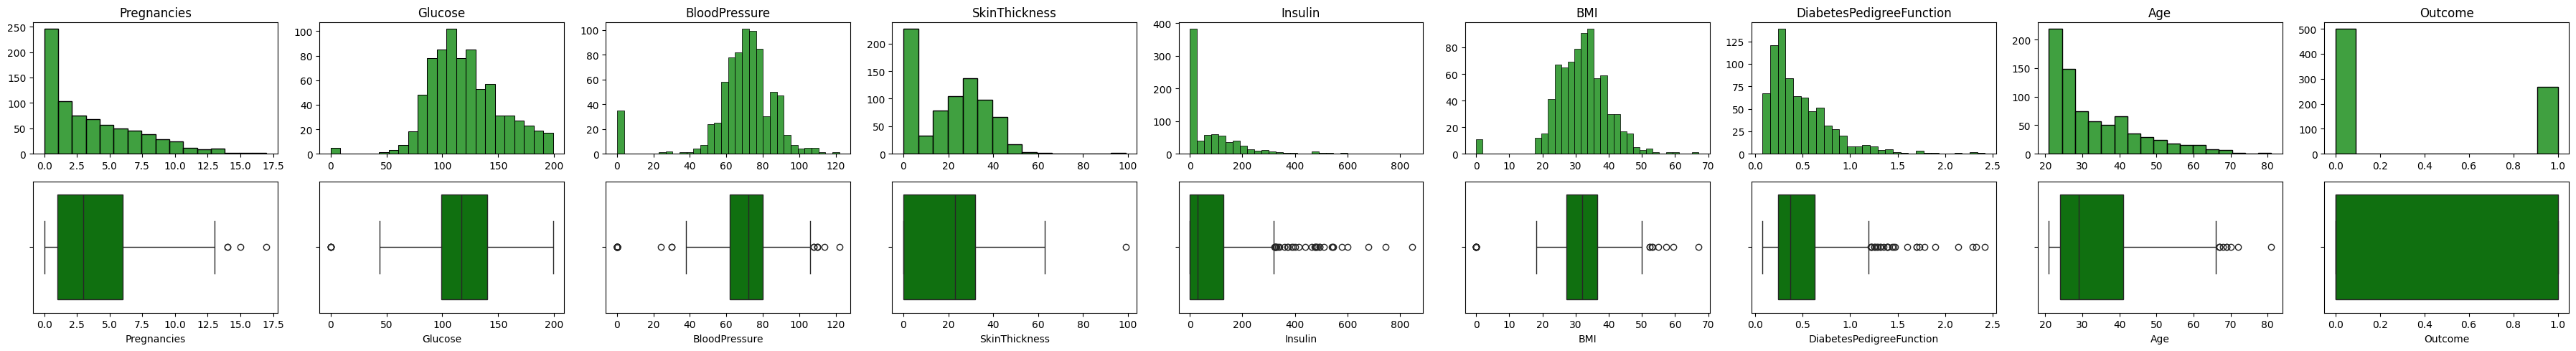

In [16]:
Col_numericas = total_data.select_dtypes("number").columns.tolist()
n = len(Col_numericas)
fig, axis = plt.subplots(2, n, figsize=(4*n, 5))

for i, col in enumerate(Col_numericas):

    sns.histplot(data=total_data, x=col, ax=axis[0, i], color="green")
    axis[0, i].set_title(col)
    axis[0, i].set_xlabel(None)
    axis[0, i].set_ylabel(None)

    sns.boxplot(data=total_data, x=col, ax=axis[1, i],color="green")

for j in range(len(Col_numericas), len(axis)):
    fig.delaxes(axis[j])
    
plt.tight_layout()
plt.show()

- Tenemos una alta concentracion de pacientes jovenes, entre 20-30 años
- Notamos outlieres curiosos en "Glucose", "BloodPreassure" y "BMI" ya que marcan valor 0, esto debe ser algun fallo en la toma de informacion
- Ciertos valores de "Pregnacies" parecen un poco altos

# Analisis multivariable

Numerico - Numerico

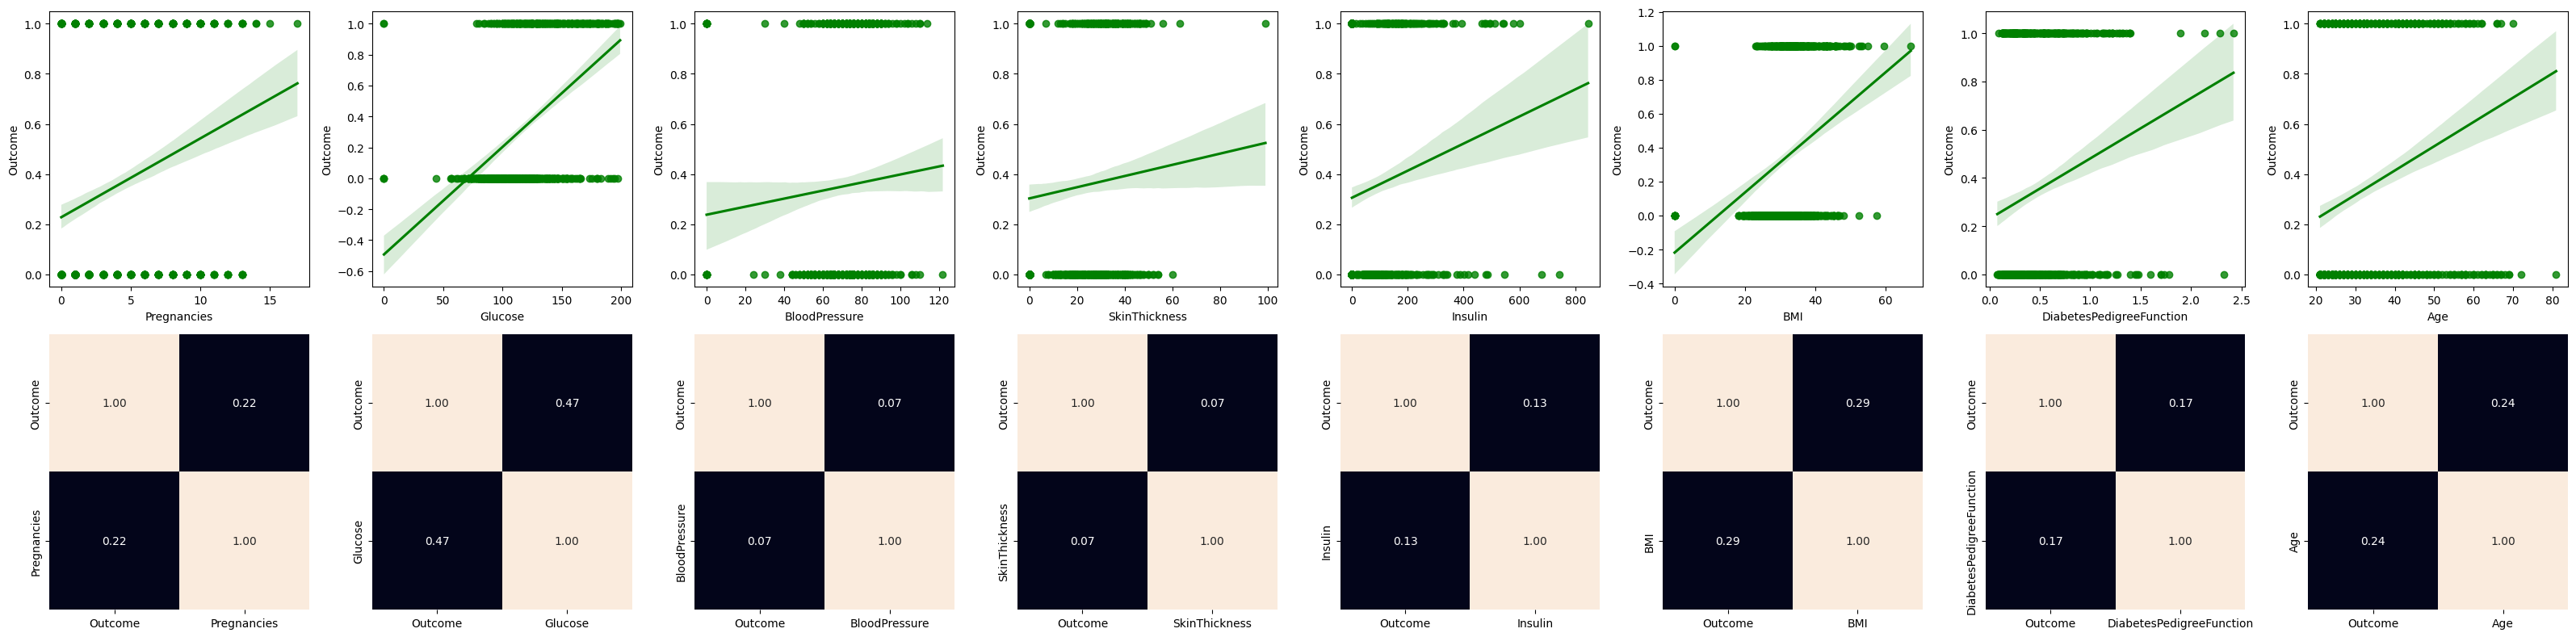

In [17]:
target= "Outcome"
col_num = [c for c in Col_numericas if c != target]
n = len(col_num)

fig, axis = plt.subplots(2, n, figsize = (n*4, 8))

for i, col in enumerate(col_num):  
    sns.regplot(ax = axis[0,i], data = total_data, x = col, y = target, color="green")
    sns.heatmap(total_data[[target, col]].corr(), annot = True, fmt = ".2f", ax = axis[1,i], cbar = False)

plt.tight_layout()
plt.show()

- Por las correlaciones mostradas podemos inferir que nuestro predictora mas importante seria "Glucose", lo cual sigue un poco con la logica comun
- La correlacion de nuestra target con "BloodPressure" es muy baja, lo cual llama un poco la atención

Categorica-Categorica: no tenemos categoricas

# Analisis de Correlacion

In [18]:
Direccion_guardado = "/workspaces/Marcos-J-Gomes_RandomForest/data/processed"
os.makedirs(Direccion_guardado, exist_ok=True)

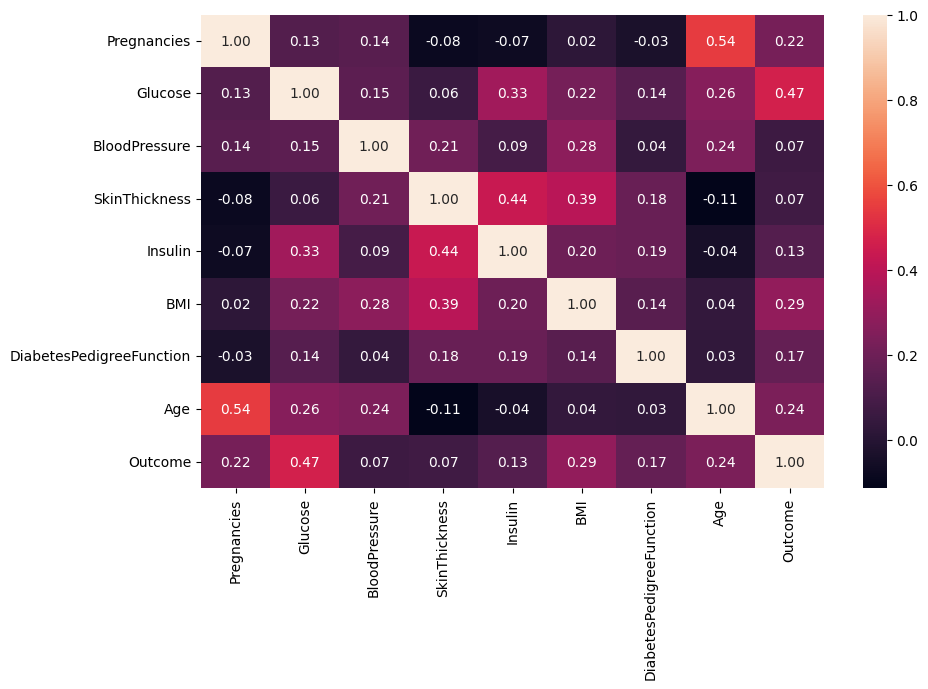

In [19]:
num_variables= Col_numericas

fig, axes = plt.subplots(figsize=(10, 7))

sns.heatmap(total_data[num_variables].corr(), annot = True, fmt = ".2f")

plt.tight_layout()
plt.show()

- La mayoria de las conclusiones sobre la correlacion de nuestra target con nuestras predictoras las marcamos en el punto anterior
- En este caso podemos resaltar ciertas correlaciones entre las predictoras, como por ejemplo la relacion entre "Age" y "Pregnancies"
- Otra relacion interesante podria ser entre "Insuline" y "SkinThickness"

# Analisis de toda la data conjunta

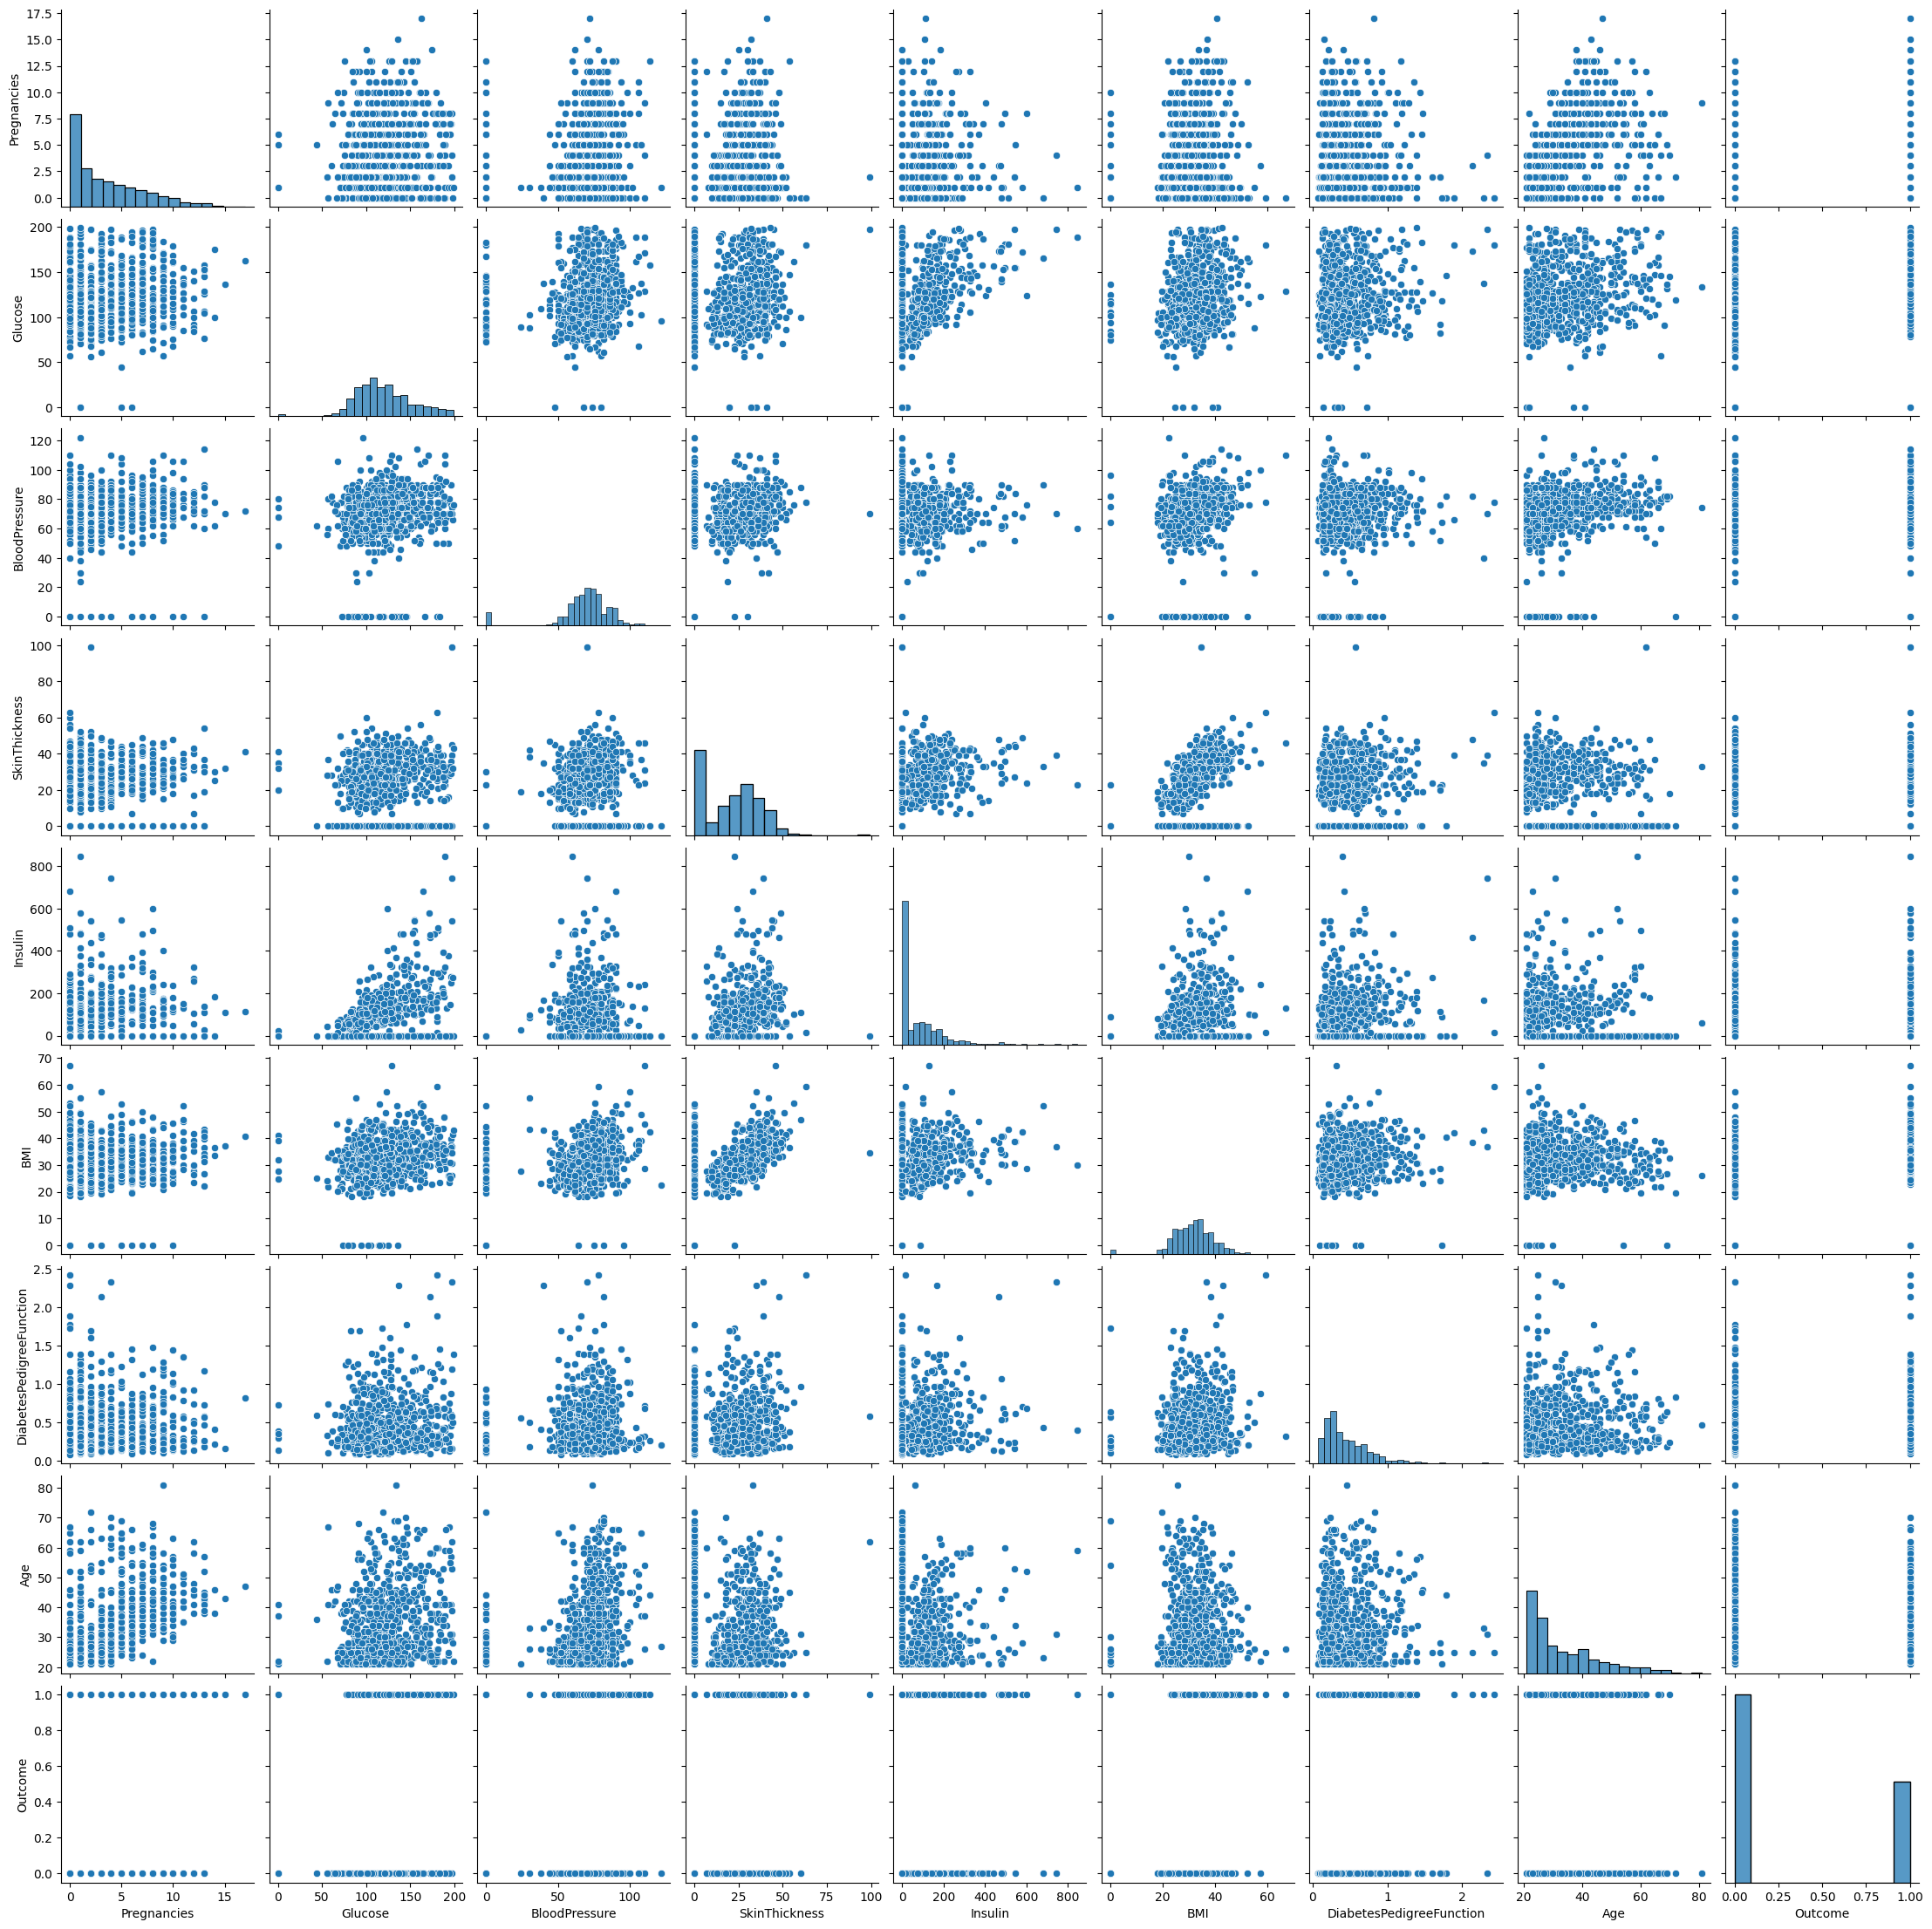

In [20]:
sns.pairplot(data = total_data)

# Feature Engineering

In [21]:
columnas_finales= num_variables
#Nos quedamos con todas las variables ya que al ser un modelo pequeño no presenta mayor inconveniente

total_data= total_data[columnas_finales]
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [22]:
total_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


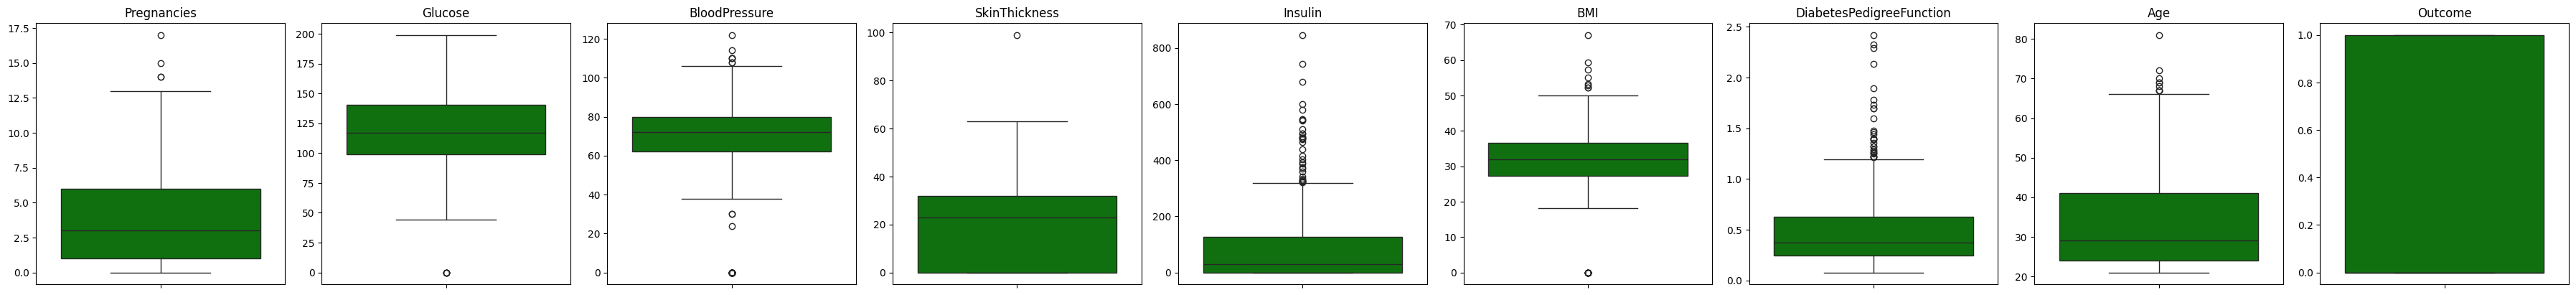

In [23]:
n_f = len(columnas_finales)
fig, axis = plt.subplots(2, n_f, figsize=(n_f*4, 8))
axis = axis.flatten() 

for i, col in enumerate(columnas_finales):
    sns.boxplot(data=total_data, y=col, ax=axis[i],color="green")
    axis[i].set_title(col)
    axis[i].set_xlabel("")
    axis[i].set_ylabel("")

for j in range(len(columnas_finales), len(axis)):
    fig.delaxes(axis[j])
    
plt.tight_layout()
plt.show()

In [24]:
for col in columnas_finales:
    stats = total_data[col].describe()
    
    q1 = stats["25%"]
    q3 = stats["75%"]
    iqr = q3 - q1
    upper_limit = q3 + 1.5 * iqr
    lower_limit = q1 - 1.5 * iqr

    print(f"Los limitires superiores e inferiores de {col} para encontrar outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(iqr, 2)}")

Los limitires superiores e inferiores de Pregnancies para encontrar outliers son 13.5 y -6.5, con un rango intercuartílico de 5.0
Los limitires superiores e inferiores de Glucose para encontrar outliers son 202.12 y 37.12, con un rango intercuartílico de 41.25
Los limitires superiores e inferiores de BloodPressure para encontrar outliers son 107.0 y 35.0, con un rango intercuartílico de 18.0
Los limitires superiores e inferiores de SkinThickness para encontrar outliers son 80.0 y -48.0, con un rango intercuartílico de 32.0
Los limitires superiores e inferiores de Insulin para encontrar outliers son 318.12 y -190.88, con un rango intercuartílico de 127.25
Los limitires superiores e inferiores de BMI para encontrar outliers son 50.55 y 13.35, con un rango intercuartílico de 9.3
Los limitires superiores e inferiores de DiabetesPedigreeFunction para encontrar outliers son 1.2 y -0.33, con un rango intercuartílico de 0.38
Los limitires superiores e inferiores de Age para encontrar outliers 

Limpieza de outliners

In [25]:
total_data = total_data.copy()

total_data_CON_outliers = total_data.copy()
total_data_SIN_outliers = total_data.copy() # Lo vamos a modificar. Para cada variable con outliers, reemplazamos sus valores outliers

outliers_cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction" ]


def replace_outliers(column, df):

    stats = df[column].describe()
    iqr = stats["75%"] - stats["25%"]

    upper = stats["75%"] + 1.5 * iqr
    lower = stats["25%"] - 1.5 * iqr

    # Solo forzamos límite positivo si la columna NO permite ceros
    if lower < 0:
        lower = df[column].min()


    df[column] = df[column].clip(lower, upper)

    return df.copy(), [int(round(lower, 2)), int(round(upper, 2))]


outliers_dict = {}
for column in outliers_cols:
    total_data_SIN_outliers, limits = replace_outliers(column, total_data_SIN_outliers)
    outliers_dict[column] = limits

outliers_dict


{'Pregnancies': [0, 13],
 'Glucose': [37, 202],
 'BloodPressure': [35, 107],
 'SkinThickness': [0, 80],
 'Insulin': [0, 318],
 'BMI': [13, 50],
 'DiabetesPedigreeFunction': [0, 1]}

In [26]:
# Guardamos los outliners

with open(f"{Direccion_guardado}/outliers_dict.json", "w") as f:
  json.dump(outliers_dict, f)

Revisamos nulos

In [27]:
total_data_CON_outliers.isnull().sum().sort_values(ascending=False)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [28]:
total_data_SIN_outliers.isnull().sum().sort_values(ascending=False)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Featuring Scaling

In [29]:
print(total_data_CON_outliers.columns)


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')


In [30]:
columnas_finales

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [31]:
# Dividimos en 2 nuestro dataset, Con y Sin Ouliers y a su vez dividimos estos en "Train" y "Test"
 
predictoras = columnas_finales.copy()
target = 'Outcome'
if target in predictoras:
    predictoras.remove(target)

print(predictoras)

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [32]:
X_CON = total_data_CON_outliers[predictoras]
X_SIN = total_data_SIN_outliers[predictoras]
y = total_data_CON_outliers[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size = 0.2, random_state = 42)
X_train_SIN_outliers, X_test_SIN_outliers = train_test_split(X_SIN, test_size = 0.2, random_state = 42)

In [33]:
X_train_CON_outliers.to_excel(f"{Direccion_guardado}/X_train_CON_outliers.xlsx", index = False)
X_train_SIN_outliers.to_excel(f"{Direccion_guardado}/X_train_SIN_outliers.xlsx", index = False)


X_test_CON_outliers.to_excel(f"{Direccion_guardado}/X_test_CON_outliers.xlsx", index = False)
X_test_SIN_outliers.to_excel(f"{Direccion_guardado}/X_test_SIN_outliers.xlsx", index = False)

y_train.to_excel(f"{Direccion_guardado}/y_train.xlsx", index = False)
y_test.to_excel(f"{Direccion_guardado}/y_test.xlsx", index = False)


# Feacture selection

Con outliers

In [34]:
X_train = X_train_CON_outliers.copy()
X_test = X_test_CON_outliers.copy()

selection_model = SelectKBest(k = 7)
selection_model.fit(X_train, y_train)

ix = selection_model.get_support()
X_train_sel_CON_outliers = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel_CON_outliers = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

In [35]:
print(X_train_sel_CON_outliers.head()) 

   Pregnancies  Glucose  BloodPressure  Insulin   BMI  \
0          2.0     84.0            0.0      0.0   0.0   
1          9.0    112.0           82.0      0.0  28.2   
2          1.0    139.0           46.0     83.0  28.7   
3          0.0    161.0           50.0      0.0  21.9   
4          6.0    134.0           80.0    370.0  46.2   

   DiabetesPedigreeFunction   Age  
0                     0.304  21.0  
1                     1.282  50.0  
2                     0.654  22.0  
3                     0.254  65.0  
4                     0.238  46.0  


In [36]:
print(X_test_sel_CON_outliers.head())

   Pregnancies  Glucose  BloodPressure  Insulin   BMI  \
0          6.0     98.0           58.0    190.0  34.0   
1          2.0    112.0           75.0      0.0  35.7   
2          2.0    108.0           64.0      0.0  30.8   
3          8.0    107.0           80.0      0.0  24.6   
4          7.0    136.0           90.0      0.0  29.9   

   DiabetesPedigreeFunction   Age  
0                     0.430  43.0  
1                     0.148  21.0  
2                     0.158  21.0  
3                     0.856  34.0  
4                     0.210  50.0  


In [37]:
X_train_sel_CON_outliers[target] = list(y_train)
X_test_sel_CON_outliers[target] = list(y_test)
X_train_sel_CON_outliers.to_csv(f"{Direccion_guardado}/X_train_sel_CON_outliers_clean.csv", index = False)
X_test_sel_CON_outliers.to_csv(f"{Direccion_guardado}/X_test_sel_CON_outliers_clean.csv", index = False)

Sin Outliners

In [38]:
X_train = X_train_SIN_outliers.copy()
X_test = X_test_SIN_outliers.copy()

# Con un valor de k = 5 decimos que seleccionamos 4 caracteristicas
selection_model = SelectKBest( k = 7)
selection_model.fit(X_train, y_train)

ix = selection_model.get_support()
X_train_sel_SIN_outliers = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel_SIN_outliers = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

In [39]:
print(X_train_sel_SIN_outliers.head())

   Pregnancies  Glucose  BloodPressure  Insulin    BMI  \
0          2.0     84.0           35.0    0.000  13.35   
1          9.0    112.0           82.0    0.000  28.20   
2          1.0    139.0           46.0   83.000  28.70   
3          0.0    161.0           50.0    0.000  21.90   
4          6.0    134.0           80.0  318.125  46.20   

   DiabetesPedigreeFunction   Age  
0                     0.304  21.0  
1                     1.200  50.0  
2                     0.654  22.0  
3                     0.254  65.0  
4                     0.238  46.0  


In [40]:
print(X_test_sel_SIN_outliers.head()) 

   Pregnancies  Glucose  BloodPressure  Insulin   BMI  \
0          6.0     98.0           58.0    190.0  34.0   
1          2.0    112.0           75.0      0.0  35.7   
2          2.0    108.0           64.0      0.0  30.8   
3          8.0    107.0           80.0      0.0  24.6   
4          7.0    136.0           90.0      0.0  29.9   

   DiabetesPedigreeFunction   Age  
0                     0.430  43.0  
1                     0.148  21.0  
2                     0.158  21.0  
3                     0.856  34.0  
4                     0.210  50.0  


In [41]:
X_train_sel_SIN_outliers[target] = list(y_train)
X_test_sel_SIN_outliers[target] = list(y_test)
X_train_sel_SIN_outliers.to_csv(f"{Direccion_guardado}/X_train_sel_SIN_outliers_clean.csv", index = False)
X_test_sel_SIN_outliers.to_csv(f"{Direccion_guardado}/X_test_sel_SIN_outliers_clean.csv", index = False)